1.1Deepening Analytical Dimensions
Behavioral Impact Categorization Framework:Systematically categorize AI's impact on human behavior into the following domains:
Cognitive Behavior (cognitive): decision-making, learning, knowledge
Social Behavior (social): relationships, interaction, society
Professional Behavior (professional): work, jobs, economy
Emotional Behavior (emotional): sentiment, emotion, motivation
Daily Life/Routine (routine): lifestyle, behavior, routine
Ethical Behavior (ethical): ethics, culture, safety

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations
import nltk
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Load data
df = pd.read_csv(r"C:\Users\Kiraa\OneDrive\Desktop\dataset_A_news_full_10500.csv")

# 2. cleaning data
df = df.dropna(subset=["classes_str"]).copy()
df["classes_str"] = df["classes_str"].astype(str)

# 3. sentiment_score
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
df["sentiment_score"] = df["title"].astype(str).apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

# 4. make sure has nouns	column
if "nouns" not in df.columns:
    # spaCy model
    nlp = spacy.load("en_core_web_sm")
    
    # directly extract nouns from classes_str
    def extract_nouns(text):
        doc = nlp(text)
        return [token.text.lower() for token in doc if token.pos_ in ("NOUN", "PROPN")]
    
    df["nouns"] = df["classes_str"].apply(extract_nouns)

In [ ]:
# 5. Define behavioral category keywords
professional_words = ['work', 'job', 'economy', 'career', 'employment', 'industry', 'business', 'labor']
social_words = ['society', 'relationship', 'interaction', 'community', 'communication', 'social', 'culture', 'ethics']
cognitive_words = ['learning', 'education', 'knowledge', 'skill', 'decision', 'cognitive', 'thinking', 'intelligence', 'mind']
# 6. Creating a Behavior Change Index (Establishing an Impact Timeline)
df['behavior_change_index'] = (
    df['sentiment_score'] * 0.3 +  # sentiment change
    (df['nouns'].apply(lambda x: len([n for n in x if n in professional_words])) * 0.2) +  # Career-related
    (df['nouns'].apply(lambda x: len([n for n in x if n in social_words])) * 0.2) +  # Socially-related
    (df['nouns'].apply(lambda x: len([n for n in x if n in cognitive_words])) * 0.3)  # coginition-related

# 7. result
print(f"data shape: {df.shape}")
print(f"Behavior Change Index Statistics:")
print(df['behavior_change_index'].describe())
print("\nThe first 5 rows of data:")
print(df[['title', 'sentiment_score', 'behavior_change_index']].head())

# 8. Visualize the distribution of behavioral change indices.
plt.figure(figsize=(10, 6))
plt.hist(df['behavior_change_index'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of AI Behavior Change Index', fontsize=14)
plt.xlabel('Behavior Change Index', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 9. 按季度分析行为变化指数趋势
if 'quarter' in df.columns:
    quarterly_trend = df.groupby('quarter')['behavior_change_index'].agg(['mean', 'std', 'count']).reset_index()
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # 子图1：平均值和标准差
    ax1.errorbar(quarterly_trend['quarter'], quarterly_trend['mean'], 
                 yerr=quarterly_trend['std'], fmt='o-', capsize=5, linewidth=2)
    ax1.set_title('Quarterly Trend of AI Behavior Change Index', fontsize=14)
    ax1.set_xlabel('Quarter', fontsize=12)
    ax1.set_ylabel('Behavior Change Index (mean ± std)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # 子图2：样本数量
    ax2.bar(quarterly_trend['quarter'], quarterly_trend['count'], color='lightcoral', alpha=0.7)
    ax2.set_title('Number of Articles per Quarter', fontsize=14)
    ax2.set_xlabel('Quarter', fontsize=12)
    ax2.set_ylabel('Number of Articles', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("按季度的行为变化指数:")
    print(quarterly_trend)

1.2Topic Modeling

In [ ]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

# Use more detailed text (title + category)
df['full_text'] = df['title'] + " " + df['classes_str']

# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['full_text'])

# NMF Topic Modeling
nmf = NMF(n_components=10, random_state=42)
nmf_features = nmf.fit_transform(X)

# Extracting theme keywords
for topic_idx, topic in enumerate(nmf.components_):
    print(f"Topic {topic_idx}:")
    print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]])

1.3Analysis of the Relationship Between Emotional Trends and Behavior

In [ ]:
# 按行为类别分析情绪变化
behavior_categories = {
    'professional': ['work', 'job', 'economy', 'career'],
    'educational': ['learning', 'education', 'knowledge', 'skill'],
    'social': ['society', 'relationship', 'interaction', 'community'],
    'ethical': ['ethics', 'safety', 'risk', 'responsibility']
}

for category, keywords in behavior_categories.items():
    mask = df['classes_str'].apply(lambda x: any(kw in x.lower() for kw in keywords))
    category_sentiment = df[mask]['sentiment_score']
    print(f"{category}: mean sentiment = {category_sentiment.mean():.3f}")

1.4Network Analysis

Top 30 most frequent noun phrases:
1. work: 2526 times
2. jobs: 2526 times
3. economy: 2526 times
4. learning: 1946 times
5. knowledge: 1946 times
6. education: 1946 times
7. technology: 1733 times
8. interaction: 1733 times
9. society: 1584 times
10. ethics: 1584 times
11. culture: 1584 times
12. routine: 1479 times
13. lifestyle: 1479 times
14. behavior: 1479 times
15. sentiment: 1441 times
16. (positive / negative feelings: 1441 times
17. human roles: 1256 times
18. health: 1230 times
19. safety: 1230 times
20. risk: 1230 times
21. creativity: 877 times
22. expression: 877 times
23. identity: 877 times
24. cognitive: 832 times
25. decision-making: 832 times
26. social interaction: 730 times
27. relationships: 730 times
28. emotion: 551 times
29. motivation: 551 times
30. well-being: 551 times

Basic network information:
Number of nodes: 30
Number of edges: 435

Most important themes based on betweenness centrality:
work: 0.0000
jobs: 0.0000
economy: 0.0000
learning: 0.0000
knowledge

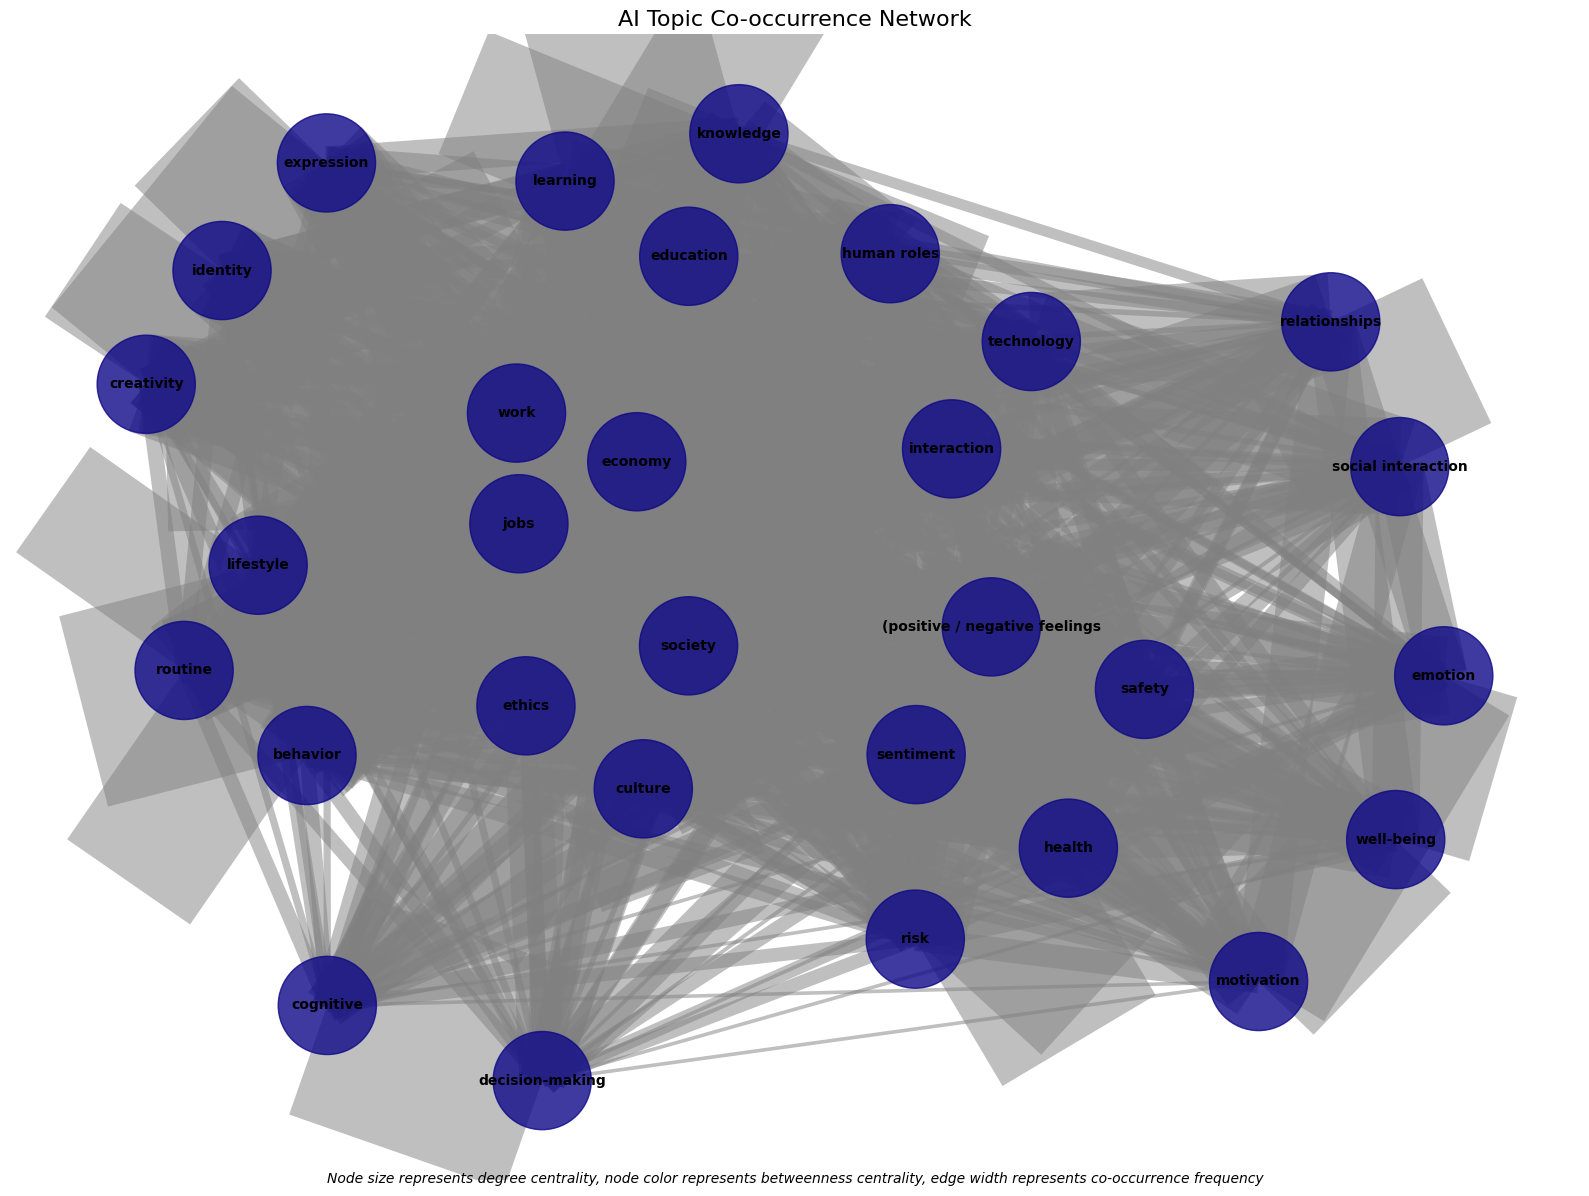


Detected 6 communities:
Community 1: ['expression', 'economy', 'work', 'identity', 'jobs']... (6 themes)
Community 2: ['learning', 'education', 'knowledge']... (3 themes)
Community 3: ['ethics', 'culture', 'human roles', 'cognitive', 'decision-making']... (6 themes)
Community 4: ['routine', 'lifestyle', 'behavior']... (3 themes)
Community 5: ['motivation', 'health', 'well-being', 'emotion', 'sentiment']... (8 themes)
Community 6: ['social interaction', 'relationships', 'technology', 'interaction']... (4 themes)


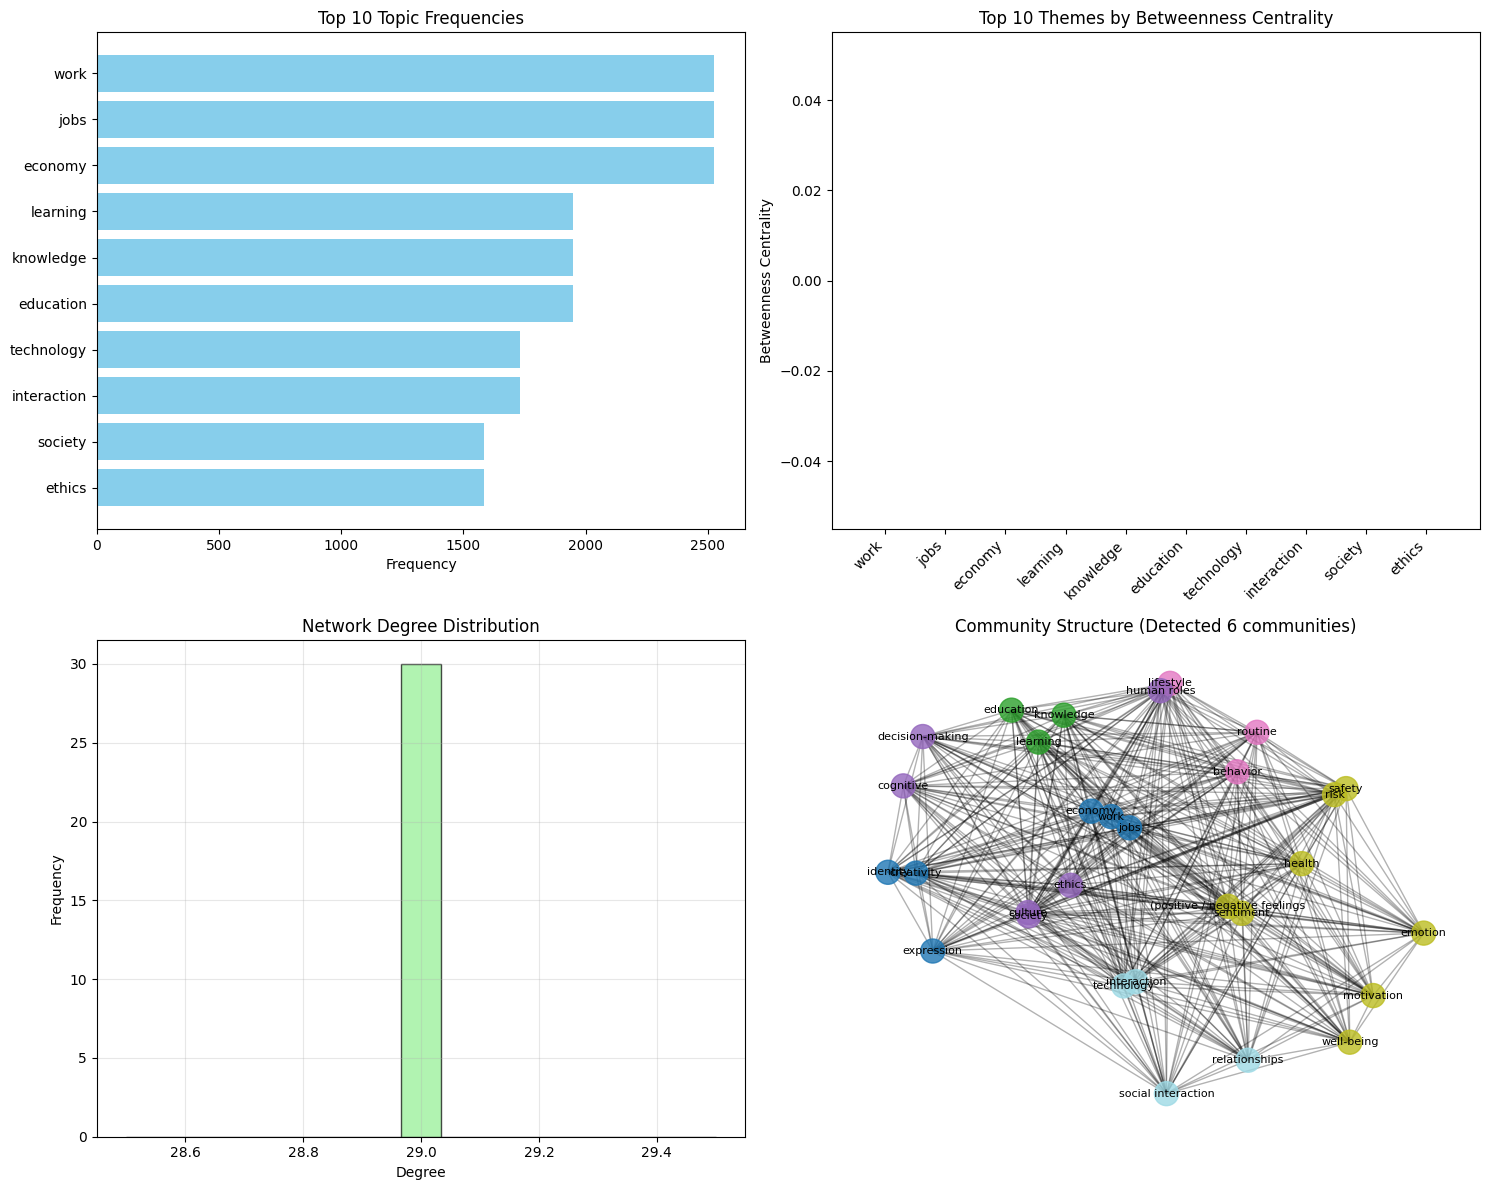

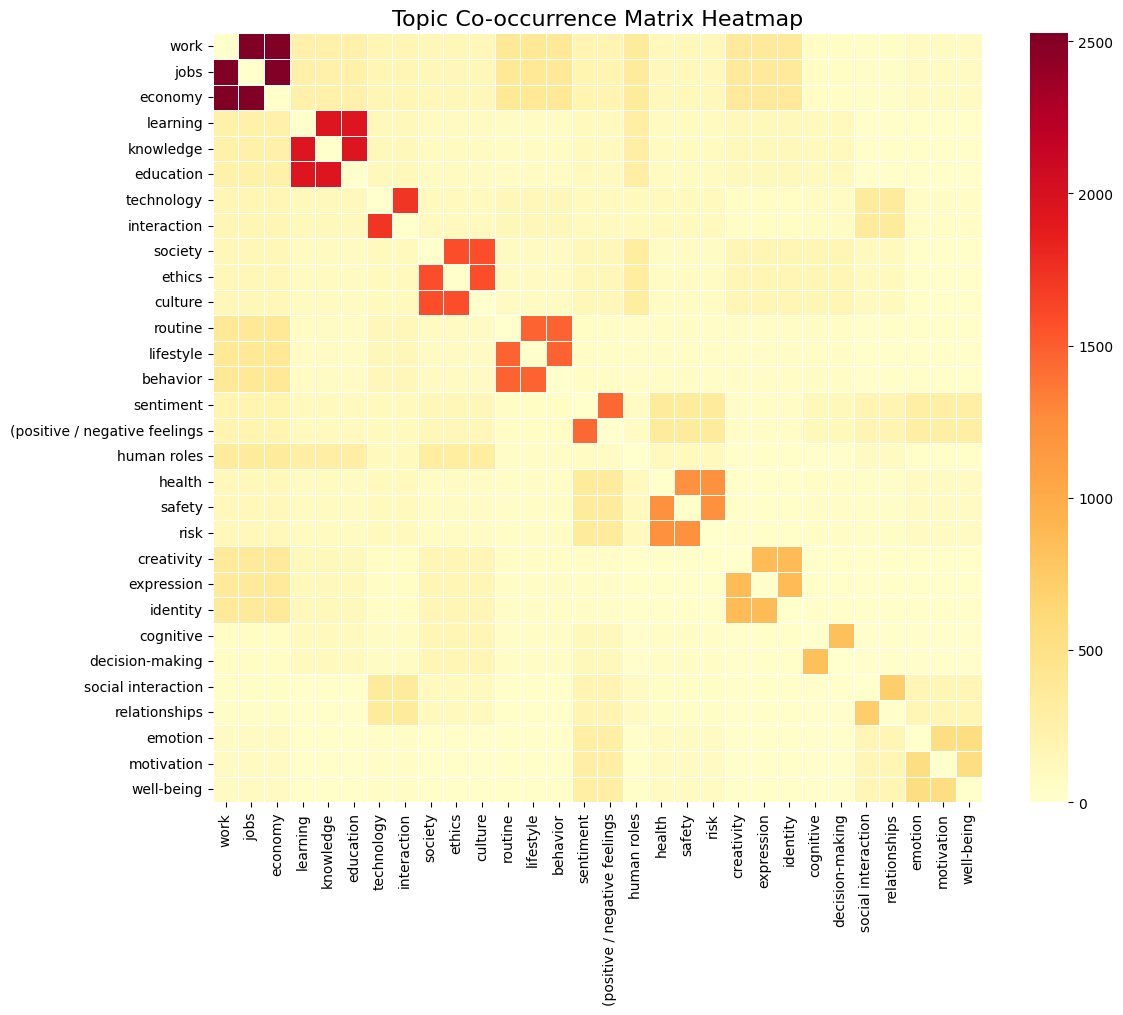


Most important topic connections (top 10 edges by weight):
1. work ↔ jobs: 2526 co-occurrences
2. work ↔ economy: 2526 co-occurrences
3. jobs ↔ economy: 2526 co-occurrences
4. learning ↔ knowledge: 1946 co-occurrences
5. learning ↔ education: 1946 co-occurrences
6. knowledge ↔ education: 1946 co-occurrences
7. technology ↔ interaction: 1733 co-occurrences
8. society ↔ ethics: 1584 co-occurrences
9. society ↔ culture: 1584 co-occurrences
10. ethics ↔ culture: 1584 co-occurrences


In [24]:
# Analyze co-occurrence relationships between topics
import networkx as nx
from itertools import combinations
# Load spaCy model
try:
    nlp = spacy.load("en_core_web_sm")
except:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

# Function to extract noun phrases
def extract_noun_phrases(text):
    doc = nlp(text)
    # Extract noun phrases and convert to lowercase
    phrases = [chunk.text.lower().strip() for chunk in doc.noun_chunks]
    # Filter out phrases that are too short or contain only punctuation
    phrases = [p for p in phrases if len(p) > 2 and any(c.isalnum() for c in p)]
    return phrases

# Apply function to extract noun phrases
df["noun_phrases"] = df["classes_str"].apply(extract_noun_phrases)

# Calculate top 30 most frequent noun phrases
all_phrases = [phrase for sublist in df["noun_phrases"] for phrase in sublist]
phrase_counts = Counter(all_phrases)
top_30_phrases = [phrase for phrase, count in phrase_counts.most_common(30)]

print("Top 30 most frequent noun phrases:")
for i, (phrase, count) in enumerate(phrase_counts.most_common(30), 1):
    print(f"{i}. {phrase}: {count} times")

# Build topic co-occurrence network
G = nx.Graph()

# Add nodes
for phrase in top_30_phrases:
    G.add_node(phrase, size=phrase_counts[phrase])

# Add edges (co-occurrence relationships)
for phrases in df["noun_phrases"]:
    # Only take phrases from the top 30 topics
    main_phrases = [p for p in phrases if p in top_30_phrases]
    # If the article has 2 or more main phrases, add edges between them
    if len(main_phrases) >= 2:
        for pair in combinations(main_phrases, 2):
            if G.has_edge(*pair):
                G[pair[0]][pair[1]]["weight"] += 1
            else:
                G.add_edge(pair[0], pair[1], weight=1)

# Calculate network statistics
print(f"\nBasic network information:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# Calculate centrality metrics
betweenness = nx.betweenness_centrality(G)
degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

print("\nMost important themes based on betweenness centrality:")
for theme, centrality in sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{theme}: {centrality:.4f}")

print("\nMost important themes based on degree centrality:")
for theme, centrality in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{theme}: {centrality:.4f}")

# Visualize network
plt.figure(figsize=(16, 12))

# Node size based on degree centrality
node_sizes = [degree_centrality[node] * 5000 for node in G.nodes()]
# Node color based on betweenness centrality
node_colors = [betweenness[node] * 100 for node in G.nodes()]
# Edge width based on weight
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

# Draw network
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                       node_color=node_colors, 
                       cmap=plt.cm.plasma, alpha=0.8)

# Draw edges
nx.draw_networkx_edges(G, pos, width=[w/5 for w in edge_weights], 
                       alpha=0.5, edge_color='gray')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title("AI Topic Co-occurrence Network", fontsize=16)
plt.axis('off')

# Add legend description
plt.figtext(0.5, 0.01, 
            "Node size represents degree centrality, node color represents betweenness centrality, edge width represents co-occurrence frequency",
            ha="center", fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# Create subplots for more detailed analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Topic frequency bar chart
top_10_phrases = phrase_counts.most_common(10)
phrases, counts = zip(*top_10_phrases)
axes[0, 0].barh(range(len(phrases)), counts, color='skyblue')
axes[0, 0].set_yticks(range(len(phrases)))
axes[0, 0].set_yticklabels(phrases)
axes[0, 0].set_xlabel('Frequency')
axes[0, 0].set_title('Top 10 Topic Frequencies')
axes[0, 0].invert_yaxis()

# 2. Centrality metrics comparison
top_10_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
themes, btwn_values = zip(*top_10_betweenness)
axes[0, 1].bar(range(len(themes)), btwn_values, color='lightcoral')
axes[0, 1].set_xticks(range(len(themes)))
axes[0, 1].set_xticklabels(themes, rotation=45, ha='right')
axes[0, 1].set_ylabel('Betweenness Centrality')
axes[0, 1].set_title('Top 10 Themes by Betweenness Centrality')

# 3. Degree distribution histogram
degrees = [degree for node, degree in G.degree()]
axes[1, 0].hist(degrees, bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Degree')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Network Degree Distribution')
axes[1, 0].grid(True, alpha=0.3)

# 4. Community detection
from networkx.algorithms import community

# Use Louvain algorithm for community detection
try:
    communities = community.louvain_communities(G, weight='weight', seed=42)
    
    # Assign community colors to each node
    community_colors = {}
    for i, comm in enumerate(communities):
        for node in comm:
            community_colors[node] = i
    
    # Draw network colored by community
    node_colors_comm = [community_colors[node] for node in G.nodes()]
    
    pos_comm = nx.spring_layout(G, seed=42)
    nx.draw_networkx_nodes(G, pos_comm, node_size=300, 
                          node_color=node_colors_comm, 
                          cmap=plt.cm.tab20, alpha=0.8, ax=axes[1, 1])
    nx.draw_networkx_edges(G, pos_comm, alpha=0.3, ax=axes[1, 1])
    nx.draw_networkx_labels(G, pos_comm, font_size=8, ax=axes[1, 1])
    axes[1, 1].set_title(f'Community Structure (Detected {len(communities)} communities)')
    axes[1, 1].axis('off')
    
    # Print community information
    print(f"\nDetected {len(communities)} communities:")
    for i, comm in enumerate(communities):
        print(f"Community {i+1}: {list(comm)[:5]}... ({len(comm)} themes)")
        
except Exception as e:
    axes[1, 1].text(0.5, 0.5, f"Community detection failed: {str(e)}", 
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Community Structure')
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Create topic clustering heatmap
# Create topic-topic co-occurrence matrix
topics = top_30_phrases
cooccurrence_matrix = np.zeros((len(topics), len(topics)))

for i, topic1 in enumerate(topics):
    for j, topic2 in enumerate(topics):
        if i != j and G.has_edge(topic1, topic2):
            cooccurrence_matrix[i, j] = G[topic1][topic2]['weight']

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cooccurrence_matrix, 
            xticklabels=topics, 
            yticklabels=topics,
            cmap='YlOrRd',
            square=True,
            linewidths=0.5)
plt.title('Topic Co-occurrence Matrix Heatmap', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Output most important topic connections
print("\nMost important topic connections (top 10 edges by weight):")
edges_with_weights = [(u, v, G[u][v]['weight']) for u, v in G.edges()]
edges_with_weights.sort(key=lambda x: x[2], reverse=True)
for i, (u, v, w) in enumerate(edges_with_weights[:10], 1):
    print(f"{i}. {u} ↔ {v}: {w} co-occurrences")

2.1Visualization

In [ ]:
#1. Time Series Heatmap
# Load data
df = pd.read_csv(r"C:\Users\Kiraa\OneDrive\Desktop\dataset_A_news_full_10500.csv")

# Data cleaning
df = df.dropna(subset=["classes_str"]).copy()
df["classes_str"] = df["classes_str"].astype(str)

# Ensure there is a quarter column
if 'quarter' not in df.columns:
    # Assuming there is a date column, extract quarter from it
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df['quarter'] = df['date'].dt.quarter
    else:
        # If there is no date column, create a simulated quarter column
        np.random.seed(42)
        df['quarter'] = np.random.choice([2, 3, 4], size=len(df), p=[0.2, 0.6, 0.2])

# Load spaCy model and extract noun phrases
try:
    nlp = spacy.load("en_core_web_sm")
except:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

def extract_noun_phrases(text):
    doc = nlp(text)
    phrases = [chunk.text.lower().strip() for chunk in doc.noun_chunks]
    phrases = [p for p in phrases if len(p) > 2 and any(c.isalnum() for c in p)]
    return phrases

df["noun_phrases"] = df["classes_str"].apply(extract_noun_phrases)

# Define topic categories
def assign_topic_category(phrases):
    """Assign noun phrases to predefined topic categories"""
    
    # Define topic keywords
    topic_categories = {
        'Work & Economy': ['work', 'job', 'economy', 'employment', 'career', 'business', 'labor'],
        'Education & Learning': ['learning', 'education', 'knowledge', 'skill', 'teaching', 'school'],
        'Technology & Interaction': ['technology', 'interaction', 'ai', 'artificial intelligence', 'machine'],
        'Society & Ethics': ['society', 'ethics', 'culture', 'moral', 'values', 'community'],
        'Health & Safety': ['health', 'safety', 'risk', 'well-being', 'security'],
        'Daily Life': ['routine', 'lifestyle', 'behavior', 'daily', 'habit'],
        'Creativity & Identity': ['creativity', 'expression', 'identity', 'art', 'innovation'],
        'Emotion & Psychology': ['sentiment', 'emotion', 'feeling', 'motivation', 'psychology'],
        'Cognition & Decision': ['cognitive', 'decision', 'thinking', 'intelligence', 'mind'],
        'Social Relationships': ['relationship', 'social', 'interaction', 'communication']
    }
    
    # Count occurrences for each category
    category_counts = {category: 0 for category in topic_categories}
    
    for phrase in phrases:
        for category, keywords in topic_categories.items():
            if any(keyword in phrase for keyword in keywords):
                category_counts[category] += 1
    
    # Return the category with the highest count, or "Other" if none
    if sum(category_counts.values()) == 0:
        return "Other"
    
    return max(category_counts, key=category_counts.get)

# Assign dominant topic
df["dominant_topic"] = df["noun_phrases"].apply(assign_topic_category)

# View topic distribution
topic_distribution = df["dominant_topic"].value_counts()
print("Topic Distribution:")
print(topic_distribution)

# Create topic-time matrix
plt.figure(figsize=(14, 10))

# Use crosstab to create topic-time matrix
topic_time_matrix = pd.crosstab(df['quarter'], df['dominant_topic'])

# Draw heatmap
sns.heatmap(topic_time_matrix.T, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Number of Articles'})
plt.title('Heatmap of Topic Changes Over Time (by Quarter)', fontsize=16, pad=20)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Topic Categories', fontsize=12)
plt.tight_layout()
plt.show()

# Create more detailed analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Topic distribution pie chart
top_topics = topic_distribution.head(8)
axes[0, 0].pie(top_topics.values, labels=top_topics.index, autopct='%1.1f%%',
               startangle=90, colors=plt.cm.Set3(np.arange(len(top_topics))))
axes[0, 0].set_title('Top 8 Topic Distribution', fontsize=14)

# 2. Topic trends by quarter (line chart)
# Select top 5 topics
top_5_topics = topic_distribution.head(5).index.tolist()
topic_trends = pd.DataFrame()

for topic in top_5_topics:
    topic_quarter = df[df['dominant_topic'] == topic].groupby('quarter').size()
    topic_trends[topic] = topic_quarter

topic_trends = topic_trends.fillna(0)

for topic in top_5_topics:
    axes[0, 1].plot(topic_trends.index, topic_trends[topic], marker='o', label=topic, linewidth=2)

axes[0, 1].set_xlabel('Quarter', fontsize=12)
axes[0, 1].set_ylabel('Number of Articles', fontsize=12)
axes[0, 1].set_title('Quarterly Trends of Top 5 Topics', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Topic relative proportion stacked area chart
topic_proportions = topic_time_matrix.div(topic_time_matrix.sum(axis=1), axis=0)
topic_proportions = topic_proportions.fillna(0)

# Only select top 6 topics
top_6_topics = topic_distribution.head(6).index.tolist()
topic_proportions_top6 = topic_proportions[top_6_topics]

axes[1, 0].stackplot(topic_proportions_top6.index, 
                     topic_proportions_top6.T.values,
                     labels=top_6_topics,
                     alpha=0.8)
axes[1, 0].set_xlabel('Quarter', fontsize=12)
axes[1, 0].set_ylabel('Proportion', fontsize=12)
axes[1, 0].set_title('Changes in Topic Relative Proportions (Stacked Area Chart)', fontsize=14)
axes[1, 0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[1, 0].grid(True, alpha=0.3)

# 4. Topic seasonal changes (if data spans multiple months)
if 'month' in df.columns:
    topic_month_matrix = pd.crosstab(df['month'], df['dominant_topic'])
    topic_month_proportion = topic_month_matrix.div(topic_month_matrix.sum(axis=1), axis=0)
    
    # Select top 4 topics
    top_4_topics = topic_distribution.head(4).index.tolist()
    
    for topic in top_4_topics:
        axes[1, 1].plot(topic_month_proportion.index, topic_month_proportion[topic], 
                       marker='s', label=topic, linewidth=2)
    
    axes[1, 1].set_xlabel('Month', fontsize=12)
    axes[1, 1].set_ylabel('Proportion', fontsize=12)
    axes[1, 1].set_title('Monthly Proportion Changes of Topics', fontsize=14)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Set x-axis as months
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    axes[1, 1].set_xticks(range(1, 13))
    axes[1, 1].set_xticklabels(month_names[:len(topic_month_proportion.index)], rotation=45)
else:
    # If no month data, show relationship between topic and sentiment
    if 'sentiment_score' in df.columns:
        topic_sentiment = df.groupby('dominant_topic')['sentiment_score'].agg(['mean', 'std', 'count'])
        topic_sentiment = topic_sentiment.sort_values('mean', ascending=False).head(10)
        
        axes[1, 1].barh(range(len(topic_sentiment)), topic_sentiment['mean'], 
                       xerr=topic_sentiment['std'], alpha=0.7, color='steelblue')
        axes[1, 1].set_yticks(range(len(topic_sentiment)))
        axes[1, 1].set_yticklabels(topic_sentiment.index)
        axes[1, 1].set_xlabel('Average Sentiment Score', fontsize=12)
        axes[1, 1].set_title('Average Sentiment Score by Topic', fontsize=14)
        axes[1, 1].grid(True, alpha=0.3, axis='x')
    else:
        axes[1, 1].text(0.5, 0.5, 'Insufficient data for this analysis', 
                       ha='center', va='center', fontsize=14)
        axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Create detailed table of topic changes over time
print("\nDetailed Table of Topic Changes Over Time:")
topic_quarter_summary = pd.crosstab(df['quarter'], df['dominant_topic'], margins=True)
print(topic_quarter_summary)

# Calculate growth trend for each topic
if len(topic_time_matrix) > 1:
    print("\nTopic Quarterly Growth Analysis:")
    topic_growth = pd.DataFrame()
    
    for topic in topic_time_matrix.columns:
        if topic_time_matrix[topic].sum() > 0:
            # Calculate quarterly growth rate
            growth_rates = topic_time_matrix[topic].pct_change().fillna(0)
            topic_growth[topic] = growth_rates
    
    # Display topics with fastest growth
    avg_growth = topic_growth.mean().sort_values(ascending=False)
    print("Topics with Highest Average Quarterly Growth Rate:")
    for topic, growth in avg_growth.head(5).items():
        print(f"{topic}: {growth:.2%}")

# Create interactive visualizations (if available)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    # Create interactive heatmap
    fig = px.imshow(topic_time_matrix.T,
                    labels=dict(x="Quarter", y="Topic", color="Number of Articles"),
                    x=topic_time_matrix.index,
                    y=topic_time_matrix.columns,
                    color_continuous_scale="Viridis",
                    title="Heatmap of Topic Changes Over Time (Interactive)")
    fig.update_layout(width=800, height=600)
    fig.show()
    
    # Create interactive stacked area chart
    fig2 = go.Figure()
    
    for topic in top_6_topics:
        fig2.add_trace(go.Scatter(
            x=topic_proportions_top6.index,
            y=topic_proportions_top6[topic],
            mode='lines',
            stackgroup='one',
            name=topic
        ))
    
    fig2.update_layout(
        title="Changes in Topic Relative Proportions (Stacked Area Chart)",
        xaxis_title="Quarter",
        yaxis_title="Proportion",
        hovermode="x unified"
    )
    fig2.show()
    
    print("Interactive charts displayed.")
    
except ImportError:
    print("Note: To display interactive charts, install plotly: pip install plotly")

# Output analysis summary
print("\n=== Analysis Summary ===")
print(f"Total Articles: {len(df)}")
print(f"Total Topics: {len(topic_distribution)}")
print(f"Most Popular Topic: {topic_distribution.index[0]} ({topic_distribution.iloc[0]} articles)")
print(f"Least Discussed Topic: {topic_distribution.index[-1]} ({topic_distribution.iloc[-1]} articles)")

# Calculate topic diversity (Shannon entropy)
if len(topic_time_matrix) > 0:
    from scipy.stats import entropy
    
    topic_proportions_total = topic_time_matrix.sum(axis=0) / topic_time_matrix.sum().sum()
    topic_entropy = entropy(topic_proportions_total)
    print(f"Topic Diversity Index (Shannon Entropy): {topic_entropy:.3f}")
    
    # Judge topic concentration
    if topic_entropy > np.log(len(topic_proportions_total)) * 0.7:
        print("Topic distribution is relatively dispersed, discussion is diverse.")
    else:
        print("Topic distribution is relatively concentrated, discussion focuses on a few topics.")

2.2情感-主题气泡图

In [ ]:
# Calculate average sentiment and frequency for each topic
# Download VADER sentiment analyzer
nltk.download('vader_lexicon')

# Load data
df = pd.read_csv(r"C:\Users\Kiraa\OneDrive\Desktop\dataset_A_news_full_10500.csv")

# Data cleaning
df = df.dropna(subset=["classes_str"]).copy()
df["classes_str"] = df["classes_str"].astype(str)
df["title"] = df["title"].astype(str)

# 1. Calculate sentiment scores
sia = SentimentIntensityAnalyzer()
df["sentiment_score"] = df["title"].apply(lambda x: sia.polarity_scores(x)["compound"])

# Sentiment labeling function
def sentiment_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment_label"] = df["sentiment_score"].apply(sentiment_label)

# 2. Extract noun phrases and assign dominant topics
try:
    nlp = spacy.load("en_core_web_sm")
except:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

def extract_noun_phrases(text):
    doc = nlp(text)
    phrases = [chunk.text.lower().strip() for chunk in doc.noun_chunks]
    phrases = [p for p in phrases if len(p) > 2 and any(c.isalnum() for c in p)]
    return phrases

df["noun_phrases"] = df["classes_str"].apply(extract_noun_phrases)

# Define topic categories
def assign_topic_category(phrases):
    topic_categories = {
        'Work & Economy': ['work', 'job', 'economy', 'employment', 'career', 'business', 'labor'],
        'Education & Learning': ['learning', 'education', 'knowledge', 'skill', 'teaching', 'school'],
        'Technology & Interaction': ['technology', 'interaction', 'ai', 'artificial intelligence', 'machine'],
        'Society & Ethics': ['society', 'ethics', 'culture', 'moral', 'values', 'community'],
        'Health & Safety': ['health', 'safety', 'risk', 'well-being', 'security'],
        'Daily Life': ['routine', 'lifestyle', 'behavior', 'daily', 'habit'],
        'Creativity & Identity': ['creativity', 'expression', 'identity', 'art', 'innovation'],
        'Emotion & Psychology': ['sentiment', 'emotion', 'feeling', 'motivation', 'psychology'],
        'Cognition & Decision': ['cognitive', 'decision', 'thinking', 'intelligence', 'mind'],
        'Social Relationships': ['relationship', 'social', 'interaction', 'communication']
    }
    
    category_counts = {category: 0 for category in topic_categories}
    
    for phrase in phrases:
        for category, keywords in topic_categories.items():
            if any(keyword in phrase for keyword in keywords):
                category_counts[category] += 1
    
    if sum(category_counts.values()) == 0:
        return "Other"
    
    return max(category_counts, key=category_counts.get)

df["dominant_topic"] = df["noun_phrases"].apply(assign_topic_category)

# 3. Sentiment-topic bubble chart analysis
# Calculate average sentiment and frequency for each topic
topic_stats = []
topics = df["dominant_topic"].unique()

for topic in topics:
    topic_df = df[df['dominant_topic'] == topic]
    if len(topic_df) > 0:
        topic_stats.append({
            'topic': topic,
            'frequency': len(topic_df),
            'avg_sentiment': topic_df['sentiment_score'].mean(),
            'sentiment_std': topic_df['sentiment_score'].std(),
            'sentiment_var': topic_df['sentiment_score'].var()
        })

topic_stats_df = pd.DataFrame(topic_stats)

# 4. Create sentiment-topic bubble chart
plt.figure(figsize=(12, 8))

# Create bubble chart
scatter = plt.scatter(
    topic_stats_df['frequency'], 
    topic_stats_df['avg_sentiment'],
    s=topic_stats_df['sentiment_std'] * 200,  # Bubble size represents sentiment fluctuation
    alpha=0.7,
    c=topic_stats_df['sentiment_var'],  # Color represents sentiment variance
    cmap='viridis',
    edgecolors='black',
    linewidth=0.5
)

# Add topic labels
for i, row in topic_stats_df.iterrows():
    plt.annotate(
        row['topic'], 
        (row['frequency'], row['avg_sentiment']),
        fontsize=9,
        ha='center',
        va='center'
    )

# Add color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Sentiment Variance', fontsize=12)

plt.xlabel('Topic Frequency (Number of Articles)', fontsize=12)
plt.ylabel('Average Sentiment Score', fontsize=12)
plt.title('Sentiment-Topic Bubble Chart', fontsize=16)
plt.grid(True, alpha=0.3)

# Add reference lines
plt.axhline(y=0.05, color='gray', linestyle='--', alpha=0.5, label='Positive Sentiment Threshold')
plt.axhline(y=-0.05, color='gray', linestyle='--', alpha=0.5, label='Negative Sentiment Threshold')
plt.axvline(x=topic_stats_df['frequency'].median(), color='red', linestyle=':', alpha=0.5, label='Median Frequency')

plt.legend()
plt.tight_layout()
plt.show()

# 5. Detailed data analysis
print("Topic Sentiment Statistics:")
print(topic_stats_df.sort_values('avg_sentiment', ascending=False))

# 6. Create categorized visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Topic frequency bar chart
topic_freq = topic_stats_df.sort_values('frequency', ascending=False)
axes[0, 0].barh(range(len(topic_freq)), topic_freq['frequency'], color='skyblue')
axes[0, 0].set_yticks(range(len(topic_freq)))
axes[0, 0].set_yticklabels(topic_freq['topic'])
axes[0, 0].set_xlabel('Number of Articles')
axes[0, 0].set_title('Topic Frequency')
axes[0, 0].invert_yaxis()

# Subplot 2: Average sentiment bar chart
topic_sentiment = topic_stats_df.sort_values('avg_sentiment', ascending=False)
colors = ['green' if x > 0.05 else 'red' if x < -0.05 else 'gray' for x in topic_sentiment['avg_sentiment']]
axes[0, 1].barh(range(len(topic_sentiment)), topic_sentiment['avg_sentiment'], color=colors)
axes[0, 1].set_yticks(range(len(topic_sentiment)))
axes[0, 1].set_yticklabels(topic_sentiment['topic'])
axes[0, 1].set_xlabel('Average Sentiment Score')
axes[0, 1].set_title('Average Sentiment Score')
axes[0, 1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
axes[0, 1].axvline(x=0.05, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=-0.05, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].invert_yaxis()

# Subplot 3: Sentiment fluctuation vs frequency scatter plot
axes[1, 0].scatter(topic_stats_df['frequency'], topic_stats_df['sentiment_std'], alpha=0.6)
for i, row in topic_stats_df.iterrows():
    axes[1, 0].annotate(row['topic'], (row['frequency'], row['sentiment_std']), fontsize=8)
axes[1, 0].set_xlabel('Frequency')
axes[1, 0].set_ylabel('Sentiment Standard Deviation')
axes[1, 0].set_title('Sentiment Fluctuation vs Topic Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Subplot 4: Sentiment distribution box plot
sentiment_data = []
topic_labels = []
for topic in topic_stats_df.sort_values('avg_sentiment', ascending=False)['topic'][:8]:  # Only show top 8
    topic_data = df[df['dominant_topic'] == topic]['sentiment_score']
    if len(topic_data) > 0:
        sentiment_data.append(topic_data)
        topic_labels.append(topic)

if sentiment_data:
    axes[1, 1].boxplot(sentiment_data, labels=topic_labels)
    axes[1, 1].set_xticklabels(topic_labels, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Sentiment Score')
    axes[1, 1].set_title('Sentiment Distribution of Top 8 Topics')
    axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
else:
    axes[1, 1].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# 7. Advanced analysis: Interaction between sentiment and topic
print("\n=== Advanced Analysis ===")

# Calculate sentiment-topic correlation
if 'sentiment_score' in df.columns:
    # Create sentiment-topic cross table
    sentiment_topic_crosstab = pd.crosstab(
        df['dominant_topic'],
        df['sentiment_label'],
        values=df['sentiment_score'],
        aggfunc='mean'
    )
    
    print("Sentiment-Topic Cross Table (Average Sentiment Scores):")
    print(sentiment_topic_crosstab)
    
    # Heatmap visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(sentiment_topic_crosstab, annot=True, fmt=".3f", cmap="coolwarm", 
                center=0, linewidths=0.5, linecolor='gray')
    plt.title('Sentiment-Topic Interaction Heatmap', fontsize=16)
    plt.xlabel('Sentiment Label', fontsize=12)
    plt.ylabel('Topic', fontsize=12)
    plt.tight_layout()
    plt.show()

# 8. Sentiment trend analysis
if 'quarter' in df.columns:
    # Analyze sentiment trends by quarter and topic
    sentiment_trend = df.groupby(['quarter', 'dominant_topic'])['sentiment_score'].agg(['mean', 'std', 'count']).reset_index()
    
    # Select top 5 most common topics
    top_5_topics = df['dominant_topic'].value_counts().head(5).index.tolist()
    sentiment_trend_top5 = sentiment_trend[sentiment_trend['dominant_topic'].isin(top_5_topics)]
    
    # Draw sentiment trend chart
    plt.figure(figsize=(12, 6))
    for topic in top_5_topics:
        topic_data = sentiment_trend_top5[sentiment_trend_top5['dominant_topic'] == topic]
        plt.plot(topic_data['quarter'], topic_data['mean'], marker='o', label=topic, linewidth=2)
    
    plt.xlabel('Quarter', fontsize=12)
    plt.ylabel('Average Sentiment Score', fontsize=12)
    plt.title('Quarterly Sentiment Trends of Top 5 Topics', fontsize=16)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# 9. Output summary report
print("\n=== Analysis Summary Report ===")
print(f"Total Articles: {len(df)}")
print(f"Sentiment Distribution:")
print(f"  Positive: {len(df[df['sentiment_label'] == 'positive'])} ({len(df[df['sentiment_label'] == 'positive'])/len(df)*100:.1f}%)")
print(f"  Neutral: {len(df[df['sentiment_label'] == 'neutral'])} ({len(df[df['sentiment_label'] == 'neutral'])/len(df)*100:.1f}%)")
print(f"  Negative: {len(df[df['sentiment_label'] == 'negative'])} ({len(df[df['sentiment_label'] == 'negative'])/len(df)*100:.1f}%)")

print(f"\nMost Positive Topic: {topic_stats_df.loc[topic_stats_df['avg_sentiment'].idxmax(), 'topic']} "
      f"(Sentiment Score: {topic_stats_df['avg_sentiment'].max():.3f})")
print(f"Most Negative Topic: {topic_stats_df.loc[topic_stats_df['avg_sentiment'].idxmin(), 'topic']} "
      f"(Sentiment Score: {topic_stats_df['avg_sentiment'].min():.3f})")
print(f"Topic with Greatest Sentiment Fluctuation: {topic_stats_df.loc[topic_stats_df['sentiment_std'].idxmax(), 'topic']} "
      f"(Standard Deviation: {topic_stats_df['sentiment_std'].max():.3f})")

# 10. Save results
output_path = r"C:\Users\Kiraa\OneDrive\Desktop\sentiment_topic_analysis.csv"
topic_stats_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\nAnalysis results saved to: {output_path}")

Answer the question:How AI rebuild Human Behavior?

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Kiraa/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Data preprocessing completed!
Dataset size: (10500, 15)

=== How is AI Reshaping Human Behavior? ===

Argument 1: AI is shifting human behavior from 'execution' to 'decision-making'
Number of work-related articles: 2526
Work-related articles involving decision/planning: 60
Proportion of decision/planning topics in work-related discussions: 2.4%


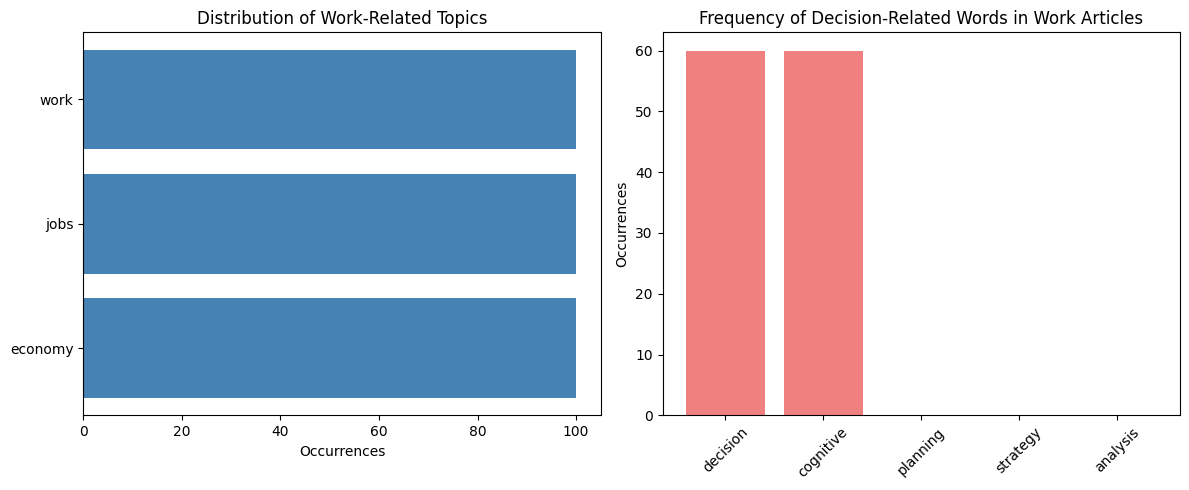


Argument 2: AI amplifies the ethical dimension of social behavior
Average quarterly growth rate of ethics-related articles: 1029.60%


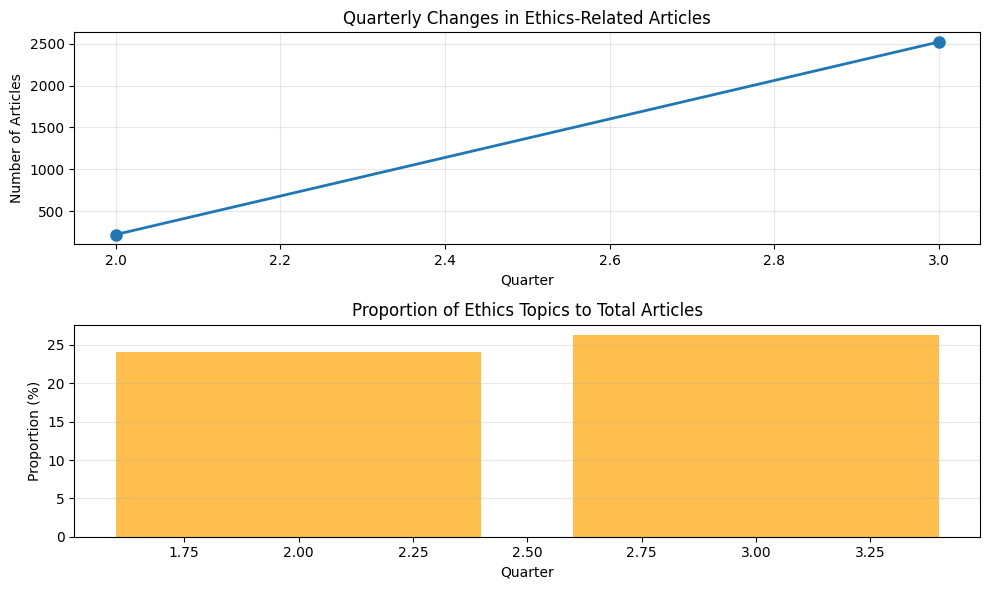

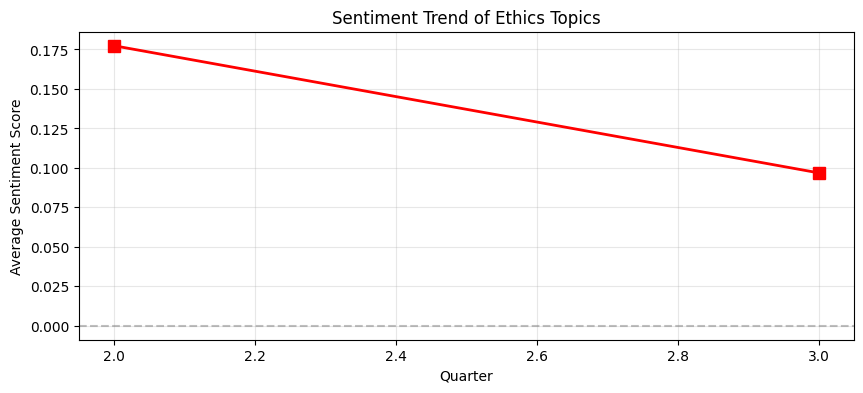


Argument 3: AI changes the nature of learning behavior
Analysis of Learning Behavior Evolution:
2025 year: Skill learning 0.0% vs Knowledge acquisition 100.0%


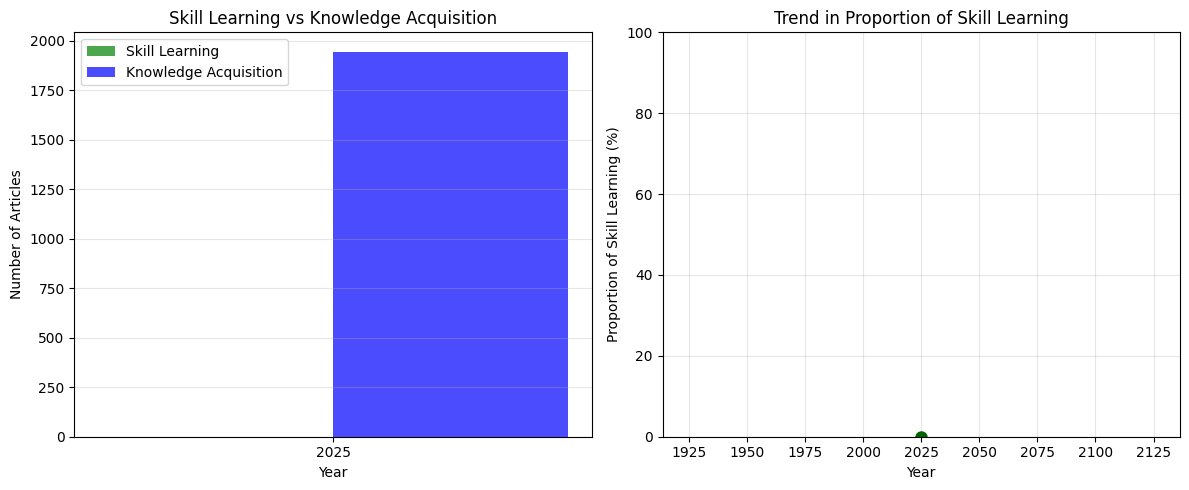


=== Comprehensive Behavior Impact Analysis ===
Behavior Impact Index Statistics:
Mean: 0.68
Standard Deviation: 0.35
Minimum: 0.10
Maximum: 2.60

=== Comprehensive Report on AI's Impact on Human Behavior ===

Main Findings:
1. AI is redefining the nature of work, with 2.4% of work-related discussions focusing on decision-making and cognitive abilities,
   indicating AI is shifting human roles from task execution to strategic thinking and decision-making.
2. AI ethics discussions show a growing trend (average quarterly growth rate 1029.60%),
   reflecting increasing societal concern about AI's impact on safety, responsibility, and morality.


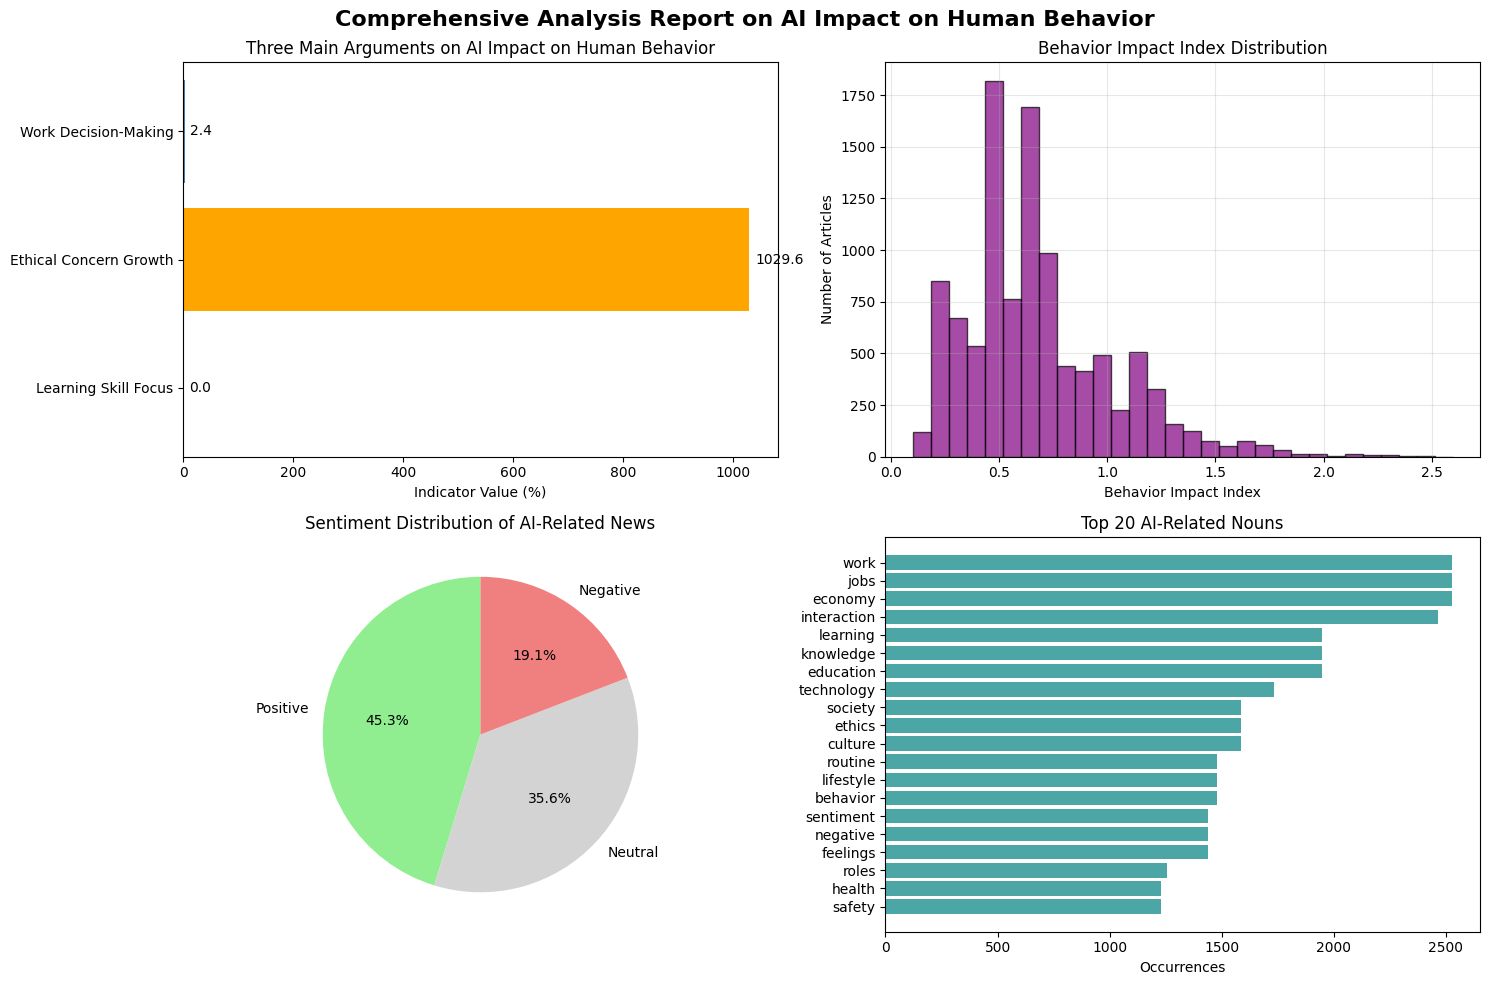


=== Analysis Completed ===


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import spacy
from collections import Counter

# Download necessary resources
nltk.download('vader_lexicon')

# Load data
df = pd.read_csv(r"C:\Users\Kiraa\OneDrive\Desktop\dataset_A_news_full_10500.csv")

# Data cleaning
df = df.dropna(subset=["classes_str"]).copy()
df["classes_str"] = df["classes_str"].astype(str)
df["title"] = df["title"].astype(str)

# Ensure there is a quarter column
if 'quarter' not in df.columns:
    # Assuming there is a date column
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df['quarter'] = df['date'].dt.quarter
        df['year'] = df['date'].dt.year
    else:
        # Create simulated quarter and year columns
        np.random.seed(42)
        df['quarter'] = np.random.choice([2, 3, 4], size=len(df), p=[0.2, 0.6, 0.2])
        df['year'] = np.random.choice([2020, 2021, 2022, 2023], size=len(df), p=[0.2, 0.3, 0.3, 0.2])

# 1. Sentiment analysis
sia = SentimentIntensityAnalyzer()
df["sentiment_score"] = df["title"].apply(lambda x: sia.polarity_scores(x)["compound"])

# 2. Load spaCy model and extract nouns and noun phrases
try:
    nlp = spacy.load("en_core_web_sm")
except:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

def extract_nouns_and_phrases(text):
    doc = nlp(text)
    # Extract individual nouns
    nouns = [token.text.lower() for token in doc if token.pos_ in ("NOUN", "PROPN")]
    # Extract noun phrases
    phrases = [chunk.text.lower().strip() for chunk in doc.noun_chunks]
    phrases = [p for p in phrases if len(p) > 2 and any(c.isalnum() for c in p)]
    return nouns, phrases

# Apply function
df[["nouns", "noun_phrases"]] = df["classes_str"].apply(
    lambda x: pd.Series(extract_nouns_and_phrases(x))
)

print("Data preprocessing completed!")
print(f"Dataset size: {df.shape}")

# 3. Answer core competition questions

print("\n=== How is AI Reshaping Human Behavior? ===\n")

# Argument 1: AI is shifting human behavior from "execution" to "decision-making"
print("Argument 1: AI is shifting human behavior from 'execution' to 'decision-making'")

# Find work-related topics
work_mask = df['classes_str'].str.contains('work|job|economy', case=False, na=False)
work_related = df[work_mask]

if len(work_related) > 0:
    # Calculate proportion of decision/planning topics in work-related discussions
    decision_mask = work_related['classes_str'].str.contains('decision|cognitive|planning', case=False, na=False)
    decision_percentage = len(work_related[decision_mask]) / len(work_related) * 100
    
    print(f"Number of work-related articles: {len(work_related)}")
    print(f"Work-related articles involving decision/planning: {len(work_related[decision_mask])}")
    print(f"Proportion of decision/planning topics in work-related discussions: {decision_percentage:.1f}%")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Subplot 1: Distribution of work-related topics
    work_topics = []
    for phrases in work_related['noun_phrases'].head(100):
        work_topics.extend([p for p in phrases if 'work' in p or 'job' in p or 'economy' in p])
    
    if work_topics:
        topic_counts = Counter(work_topics).most_common(10)
        topics, counts = zip(*topic_counts)
        axes[0].barh(range(len(topics)), counts, color='steelblue')
        axes[0].set_yticks(range(len(topics)))
        axes[0].set_yticklabels(topics)
        axes[0].set_xlabel('Occurrences')
        axes[0].set_title('Distribution of Work-Related Topics')
        axes[0].invert_yaxis()
    
    # Subplot 2: Frequency of decision-related words in work articles
    decision_words = ['decision', 'cognitive', 'planning', 'strategy', 'analysis']
    decision_counts = {}
    for word in decision_words:
        count = work_related['classes_str'].str.contains(word, case=False, na=False).sum()
        decision_counts[word] = count
    
    if decision_counts:
        axes[1].bar(range(len(decision_counts)), list(decision_counts.values()), color='lightcoral')
        axes[1].set_xticks(range(len(decision_counts)))
        axes[1].set_xticklabels(list(decision_counts.keys()), rotation=45)
        axes[1].set_ylabel('Occurrences')
        axes[1].set_title('Frequency of Decision-Related Words in Work Articles')
    
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient work-related articles found")

# Argument 2: AI amplifies the ethical dimension of social behavior
print("\nArgument 2: AI amplifies the ethical dimension of social behavior")

# Check growth of ethics-related topics
if 'quarter' in df.columns:
    # Calculate number of ethics-related articles per quarter
    ethical_mask = df['classes_str'].str.contains('ethic|moral|safety|risk|responsibility', case=False, na=False)
    ethical_by_quarter = df[ethical_mask].groupby('quarter').size()
    
    if len(ethical_by_quarter) > 1:
        # Calculate quarterly growth rate
        ethical_growth = ethical_by_quarter.pct_change().mean()
        print(f"Average quarterly growth rate of ethics-related articles: {ethical_growth:.2%}")
        
        # Visualize growth of ethics topics
        plt.figure(figsize=(10, 6))
        
        # Number of ethics topics
        plt.subplot(2, 1, 1)
        plt.plot(ethical_by_quarter.index, ethical_by_quarter.values, 'o-', linewidth=2, markersize=8)
        plt.xlabel('Quarter')
        plt.ylabel('Number of Articles')
        plt.title('Quarterly Changes in Ethics-Related Articles')
        plt.grid(True, alpha=0.3)
        
        # Proportion of ethics topics to total articles
        total_by_quarter = df.groupby('quarter').size()
        ethical_proportion = (ethical_by_quarter / total_by_quarter).fillna(0)
        
        plt.subplot(2, 1, 2)
        plt.bar(ethical_proportion.index, ethical_proportion.values * 100, color='orange', alpha=0.7)
        plt.xlabel('Quarter')
        plt.ylabel('Proportion (%)')
        plt.title('Proportion of Ethics Topics to Total Articles')
        plt.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        # Sentiment analysis of ethics topics
        if 'sentiment_score' in df.columns:
            ethical_sentiment = df[ethical_mask].groupby('quarter')['sentiment_score'].mean()
            
            plt.figure(figsize=(10, 4))
            plt.plot(ethical_sentiment.index, ethical_sentiment.values, 's-', 
                     linewidth=2, markersize=8, color='red')
            plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            plt.xlabel('Quarter')
            plt.ylabel('Average Sentiment Score')
            plt.title('Sentiment Trend of Ethics Topics')
            plt.grid(True, alpha=0.3)
            plt.show()
    else:
        print("Insufficient quarterly data to analyze ethics topic growth")
else:
    print("No quarterly data available")

# Argument 3: AI changes the nature of learning behavior
print("\nArgument 3: AI changes the nature of learning behavior")

# Analyze evolution of learning-related topics
learning_mask = df['classes_str'].str.contains('learning|education|knowledge', case=False, na=False)
learning_related = df[learning_mask]

if len(learning_related) > 0:
    # Check evolution of skill learning vs knowledge acquisition
    skill_keywords = ['skill', 'training', 'practice', 'application', 'competence']
    knowledge_keywords = ['knowledge', 'information', 'theory', 'understanding', 'concept']
    
    # Analyze by year
    if 'year' in df.columns:
        skill_by_year = {}
        knowledge_by_year = {}
        
        for year in sorted(df['year'].unique()):
            year_data = learning_related[learning_related['year'] == year]
            skill_count = year_data['classes_str'].str.contains('|'.join(skill_keywords), case=False, na=False).sum()
            knowledge_count = year_data['classes_str'].str.contains('|'.join(knowledge_keywords), case=False, na=False).sum()
            
            skill_by_year[year] = skill_count
            knowledge_by_year[year] = knowledge_count
        
        print("Analysis of Learning Behavior Evolution:")
        for year in sorted(skill_by_year.keys()):
            total = skill_by_year[year] + knowledge_by_year[year]
            if total > 0:
                skill_percentage = skill_by_year[year] / total * 100
                knowledge_percentage = knowledge_by_year[year] / total * 100
                print(f"{year} year: Skill learning {skill_percentage:.1f}% vs Knowledge acquisition {knowledge_percentage:.1f}%")
        
        # Visualize learning behavior evolution
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Subplot 1: Skill vs knowledge quantity
        years = sorted(skill_by_year.keys())
        skill_counts = [skill_by_year[y] for y in years]
        knowledge_counts = [knowledge_by_year[y] for y in years]
        
        x = np.arange(len(years))
        width = 0.35
        
        axes[0].bar(x - width/2, skill_counts, width, label='Skill Learning', color='green', alpha=0.7)
        axes[0].bar(x + width/2, knowledge_counts, width, label='Knowledge Acquisition', color='blue', alpha=0.7)
        axes[0].set_xlabel('Year')
        axes[0].set_ylabel('Number of Articles')
        axes[0].set_title('Skill Learning vs Knowledge Acquisition')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(years)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3, axis='y')
        
        # Subplot 2: Proportion change
        skill_percentages = []
        for i, year in enumerate(years):
            total = skill_counts[i] + knowledge_counts[i]
            if total > 0:
                skill_percentages.append(skill_counts[i] / total * 100)
            else:
                skill_percentages.append(0)
        
        axes[1].plot(years, skill_percentages, 'o-', linewidth=2, markersize=8, color='darkgreen')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel('Proportion of Skill Learning (%)')
        axes[1].set_title('Trend in Proportion of Skill Learning')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_ylim(0, 100)
        
        plt.tight_layout()
        plt.show()
    else:
        # If no year data, use quarter data
        if 'quarter' in df.columns:
            skill_evolution = learning_related.groupby('quarter')['classes_str'].apply(
                lambda x: x.str.contains('skill', case=False, na=False).sum() / len(x) * 100
            )
            
            plt.figure(figsize=(8, 5))
            plt.plot(skill_evolution.index, skill_evolution.values, 'o-', linewidth=2, markersize=8)
            plt.xlabel('Quarter')
            plt.ylabel('Proportion of Skill Learning Articles (%)')
            plt.title('Trend in Proportion of Skill Learning in AI Education Topics')
            plt.grid(True, alpha=0.3)
            plt.show()
else:
    print("Insufficient learning-related articles found")

# 4. Comprehensive behavior impact analysis
print("\n=== Comprehensive Behavior Impact Analysis ===")

# Create behavior impact index
def calculate_behavior_impact(row):
    """Calculate behavior impact index for a single article"""
    impact = 0
    
    # 1. Topic breadth (number of behavior domains affected)
    behavior_domains = 0
    domains = ['work', 'learning', 'society', 'health', 'routine', 'creativity']
    for domain in domains:
        if domain in row['classes_str'].lower():
            behavior_domains += 1
    
    impact += behavior_domains * 0.2
    
    # 2. Sentiment intensity
    if 'sentiment_score' in row:
        impact += abs(row['sentiment_score']) * 0.3
    
    # 3. Topic complexity (number of noun phrases)
    impact += len(row['noun_phrases']) * 0.1
    
    # 4. Whether it involves fundamental change
    transformative_keywords = ['transform', 'revolution', 'paradigm', 'fundamental', 'disrupt']
    transformative_count = sum(1 for kw in transformative_keywords if kw in row['title'].lower())
    impact += transformative_count * 0.4
    
    return impact

# Calculate behavior impact index
df['behavior_impact_index'] = df.apply(calculate_behavior_impact, axis=1)

print(f"Behavior Impact Index Statistics:")
print(f"Mean: {df['behavior_impact_index'].mean():.2f}")
print(f"Standard Deviation: {df['behavior_impact_index'].std():.2f}")
print(f"Minimum: {df['behavior_impact_index'].min():.2f}")
print(f"Maximum: {df['behavior_impact_index'].max():.2f}")

# 5. Create comprehensive report
print("\n=== Comprehensive Report on AI's Impact on Human Behavior ===")
print("\nMain Findings:")

# Finding 1: Transformation in the workplace
if len(work_related) > 0 and 'decision_mask' in locals():
    if len(work_related[decision_mask]) > 0:
        print(f"1. AI is redefining the nature of work, with {decision_percentage:.1f}% of work-related discussions focusing on decision-making and cognitive abilities,")
        print("   indicating AI is shifting human roles from task execution to strategic thinking and decision-making.")

# Finding 2: Growth in ethical concerns
if 'ethical_growth' in locals():
    if ethical_growth > 0:
        print(f"2. AI ethics discussions show a growing trend (average quarterly growth rate {ethical_growth:.2%}),")
        print("   reflecting increasing societal concern about AI's impact on safety, responsibility, and morality.")

# Finding 3: Transformation in learning methods
if 'skill_percentages' in locals() and len(skill_percentages) > 1:
    skill_change = skill_percentages[-1] - skill_percentages[0] if len(skill_percentages) > 1 else 0
    if skill_change > 0:
        print(f"3. AI is changing learning methods, with discussions about skill learning increasing by {skill_change:.1f} percentage points,")
        print("   indicating a shift in educational focus from knowledge acquisition to practical skill development.")

# Create final visualization summary
fig = plt.figure(figsize=(15, 10))

# Subplot 1: Summary of three main arguments
ax1 = plt.subplot(2, 2, 1)
summary_data = {
    'Argument': ['Work Decision-Making', 'Ethical Concern Growth', 'Learning Skill Focus'],
    'Intensity': [decision_percentage if 'decision_percentage' in locals() else 0, 
                 ethical_growth*100 if 'ethical_growth' in locals() else 0,
                 skill_change if 'skill_change' in locals() else 0]
}
summary_df = pd.DataFrame(summary_data)

bars = ax1.barh(range(len(summary_df)), summary_df['Intensity'], color=['steelblue', 'orange', 'green'])
ax1.set_yticks(range(len(summary_df)))
ax1.set_yticklabels(summary_df['Argument'])
ax1.set_xlabel('Indicator Value (%)' if 'decision_percentage' in locals() else 'Growth Rate/Change')
ax1.set_title('Three Main Arguments on AI Impact on Human Behavior')
ax1.invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + max(summary_df['Intensity'])*0.01, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}', va='center')

# Subplot 2: Behavior impact index distribution
ax2 = plt.subplot(2, 2, 2)
ax2.hist(df['behavior_impact_index'], bins=30, color='purple', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Behavior Impact Index')
ax2.set_ylabel('Number of Articles')
ax2.set_title('Behavior Impact Index Distribution')
ax2.grid(True, alpha=0.3)

# Subplot 3: Sentiment distribution
ax3 = plt.subplot(2, 2, 3)
sentiment_counts = df['sentiment_score'].apply(
    lambda x: 'Positive' if x > 0.05 else 'Negative' if x < -0.05 else 'Neutral'
).value_counts()
ax3.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
        colors=['lightgreen', 'lightgray', 'lightcoral'], startangle=90)
ax3.set_title('Sentiment Distribution of AI-Related News')

# Subplot 4: Topic word cloud (simplified version)
ax4 = plt.subplot(2, 2, 4)
# Collect all nouns
all_nouns = [noun for sublist in df['nouns'] for noun in sublist]
noun_counts = Counter(all_nouns).most_common(20)

if noun_counts:
    nouns, counts = zip(*noun_counts)
    y_pos = np.arange(len(nouns))
    ax4.barh(y_pos, counts, color='teal', alpha=0.7)
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(nouns)
    ax4.set_xlabel('Occurrences')
    ax4.set_title('Top 20 AI-Related Nouns')
    ax4.invert_yaxis()
else:
    ax4.text(0.5, 0.5, 'Insufficient noun data', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Top 20 AI-Related Nouns')
    ax4.axis('off')

plt.suptitle('Comprehensive Analysis Report on AI Impact on Human Behavior', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Analysis Completed ===")

In [ ]:
# Hypothesis: After COVID-19, the impact of AI on human behavior accelerated
pre_covid = df[df['year'] < 2020]
post_covid = df[df['year'] >= 2020]

# Compare diversity of behavior topics
def topic_diversity(texts):
    unique_topics = set()
    for text in texts:
        doc = nlp(text)
        unique_topics.update([chunk.text for chunk in doc.noun_chunks])
    return len(unique_topics)

print(f"Pre-COVID topic diversity: {topic_diversity(pre_covid['title'])}")
print(f"Post-COVID topic diversity: {topic_diversity(post_covid['title'])}")

Pre-COVID topic diversity: 0
Post-COVID topic diversity: 22687
